In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip install -q nilearn pandas numpy scipy scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 96.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [3]:
from pathlib import Path

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nilearn.glm.first_level import make_first_level_design_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
PROJECT_ROOT = Path("/content/drive/MyDrive/Proyecto_PINN_HRF")

SUBJECT_ID = "100206"

RAW_RESULTS_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / SUBJECT_ID
    / "MNINonLinear"
    / "Results"
)

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / SUBJECT_ID
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "glm"
    / SUBJECT_ID
)

FIGURES_DIR = PROJECT_ROOT / "results" / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

runs = {
    "MOTOR_LR": {
        "bold_csv": PROCESSED_DIR / "motor_lr_bilateral_bold.csv",
        "metadata": PROCESSED_DIR / "motor_lr_metadata.json",
        "events_dir": RAW_RESULTS_DIR / "tfMRI_MOTOR_LR" / "EVs",
        "motion": (
            RAW_RESULTS_DIR
            / "tfMRI_MOTOR_LR"
            / "Movement_Regressors.txt"
        ),
    },
    "MOTOR_RL": {
        "bold_csv": PROCESSED_DIR / "motor_rl_bilateral_bold.csv",
        "metadata": PROCESSED_DIR / "motor_rl_metadata.json",
        "events_dir": RAW_RESULTS_DIR / "tfMRI_MOTOR_RL" / "EVs",
        "motion": (
            RAW_RESULTS_DIR
            / "tfMRI_MOTOR_RL"
            / "Movement_Regressors.txt"
        ),
    },
}

for run_name, paths in runs.items():
    print(f"\n{run_name}")
    for key, path in paths.items():
        print(f"{key}: {path.exists()} — {path}")


MOTOR_LR
bold_csv: True — /content/drive/MyDrive/Proyecto_PINN_HRF/data/processed/100206/motor_lr_bilateral_bold.csv
metadata: True — /content/drive/MyDrive/Proyecto_PINN_HRF/data/processed/100206/motor_lr_metadata.json
events_dir: True — /content/drive/MyDrive/Proyecto_PINN_HRF/data/raw/100206/MNINonLinear/Results/tfMRI_MOTOR_LR/EVs
motion: True — /content/drive/MyDrive/Proyecto_PINN_HRF/data/raw/100206/MNINonLinear/Results/tfMRI_MOTOR_LR/Movement_Regressors.txt

MOTOR_RL
bold_csv: True — /content/drive/MyDrive/Proyecto_PINN_HRF/data/processed/100206/motor_rl_bilateral_bold.csv
metadata: True — /content/drive/MyDrive/Proyecto_PINN_HRF/data/processed/100206/motor_rl_metadata.json
events_dir: True — /content/drive/MyDrive/Proyecto_PINN_HRF/data/raw/100206/MNINonLinear/Results/tfMRI_MOTOR_RL/EVs
motion: True — /content/drive/MyDrive/Proyecto_PINN_HRF/data/raw/100206/MNINonLinear/Results/tfMRI_MOTOR_RL/Movement_Regressors.txt


In [5]:
CONDITIONS = ["cue", "lf", "lh", "rf", "rh", "t"]


def cargar_todos_los_eventos(
    events_dir: Path,
) -> pd.DataFrame:
    """
    Lee los archivos de eventos de una corrida MOTOR y construye
    una tabla compatible con Nilearn.
    """
    tablas = []

    for condition in CONDITIONS:
        event_file = events_dir / f"{condition}.txt"

        if not event_file.exists():
            raise FileNotFoundError(
                f"No se encontró el archivo {event_file}"
            )

        values = np.loadtxt(event_file, ndmin=2)

        if values.shape[1] < 3:
            raise ValueError(
                f"{event_file.name} no contiene tres columnas."
            )

        table = pd.DataFrame(
            {
                "onset": values[:, 0],
                "duration": values[:, 1],
                "trial_type": condition,
                "modulation": values[:, 2],
            }
        )

        tablas.append(table)

    events = pd.concat(tablas, ignore_index=True)
    events = events.sort_values("onset").reset_index(drop=True)

    return events

In [6]:
events_by_run = {}

for run_name, paths in runs.items():
    events = cargar_todos_los_eventos(paths["events_dir"])
    events_by_run[run_name] = events

    print(f"\n{run_name}: {len(events)} eventos")
    display(events)


MOTOR_LR: 20 eventos


,onset,duration,trial_type,modulation
0,8.050,3.0,cue,1.0
1,11.009,12.0,rh,1.0
2,23.164,3.0,cue,1.0
3,26.136,12.0,lf,1.0
4,38.291,3.0,cue,1.0
5,41.263,12.0,t,1.0
6,53.418,3.0,cue,1.0
7,56.390,12.0,rf,1.0
8,68.545,3.0,cue,1.0
9,71.517,12.0,lh,1.0



MOTOR_RL: 20 eventos


,onset,duration,trial_type,modulation
0,8.037,3.0,cue,1.0
1,10.996,12.0,lh,1.0
2,23.150,3.0,cue,1.0
3,26.123,12.0,rf,1.0
4,53.285,3.0,cue,1.0
5,56.243,12.0,t,1.0
6,68.398,3.0,cue,1.0
7,71.371,12.0,lf,1.0
8,83.526,3.0,cue,1.0
9,86.498,12.0,rh,1.0


In [7]:
def cargar_movimiento(
    motion_path: Path,
    n_volumes: int,
) -> pd.DataFrame:
    """
    Lee los regresores de movimiento del HCP.

    Se utilizan las primeras 12 columnas:
    seis parámetros de movimiento y sus derivadas.
    """
    if not motion_path.exists():
        raise FileNotFoundError(
            f"No se encontró {motion_path}"
        )

    movement = np.loadtxt(motion_path, ndmin=2)

    if movement.shape[0] != n_volumes:
        raise ValueError(
            f"Se esperaban {n_volumes} filas, "
            f"pero se encontraron {movement.shape[0]}"
        )

    if movement.shape[1] < 12:
        raise ValueError(
            "Movement_Regressors.txt contiene menos de 12 columnas."
        )

    movement = movement[:, :12]

    columns = [
        "trans_x",
        "trans_y",
        "trans_z",
        "rot_x",
        "rot_y",
        "rot_z",
        "d_trans_x",
        "d_trans_y",
        "d_trans_z",
        "d_rot_x",
        "d_rot_y",
        "d_rot_z",
    ]

    return pd.DataFrame(movement, columns=columns)

In [8]:
def construir_matriz_diseño(
    bold_table: pd.DataFrame,
    metadata: dict,
    events: pd.DataFrame,
    movement: pd.DataFrame,
) -> pd.DataFrame:
    """
    Construye una matriz GLM con HRF canónica de SPM,
    eventos MOTOR, regresores de movimiento y deriva temporal.
    """
    tr = float(metadata["tr_s"])
    n_volumes = int(metadata["n_volumes"])

    if len(bold_table) != n_volumes:
        raise ValueError(
            "La cantidad de puntos BOLD no coincide "
            "con los metadatos."
        )

    frame_times = np.arange(n_volumes, dtype=float) * tr

    design_matrix = make_first_level_design_matrix(
        frame_times=frame_times,
        events=events,
        hrf_model="spm",
        drift_model="cosine",
        high_pass=0.008,
        add_regs=movement.to_numpy(),
        add_reg_names=list(movement.columns),
        min_onset=-24,
    )

    return design_matrix

In [9]:
data_by_run = {}

for run_name, paths in runs.items():
    bold_table = pd.read_csv(paths["bold_csv"])

    with open(paths["metadata"], encoding="utf-8") as file:
        metadata = json.load(file)

    events = events_by_run[run_name]

    movement = cargar_movimiento(
        paths["motion"],
        n_volumes=int(metadata["n_volumes"]),
    )

    design_matrix = construir_matriz_diseño(
        bold_table,
        metadata,
        events,
        movement,
    )

    data_by_run[run_name] = {
        "bold": bold_table,
        "metadata": metadata,
        "events": events,
        "movement": movement,
        "design": design_matrix,
    }

    print(
        f"{run_name}: matriz de diseño "
        f"{design_matrix.shape}"
    )

    display(design_matrix.head())

[make_first_level_design_matrix] A 'modulation' column was found in the given events data and is used.

MOTOR_LR: matriz de diseño (284, 22)


,cue,lf,lh,rf,rh,t,trans_x,trans_y,trans_z,rot_x,...,d_trans_x,d_trans_y,d_trans_z,d_rot_x,d_rot_y,d_rot_z,drift_1,drift_2,drift_3,constant
0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.077867,0.064049,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.083917,0.083913,0.083907,1.0
0.72,0.0,0.0,0.0,0.0,0.0,0.0,0.030546,0.118167,0.073732,-0.056150,...,0.030546,0.040300,0.009683,-0.056150,0.042284,0.028992,0.083907,0.083872,0.083814,1.0
1.44,0.0,0.0,0.0,0.0,0.0,0.0,0.042943,0.096631,0.102270,-0.036497,...,0.012397,-0.021536,0.028538,0.019653,0.011001,-0.028992,0.083886,0.083790,0.083629,1.0
2.16,0.0,0.0,0.0,0.0,0.0,0.0,-0.022272,0.098279,0.077704,-0.027215,...,-0.065215,0.001648,-0.024566,0.009282,-0.030596,0.000000,0.083855,0.083667,0.083353,1.0
2.88,0.0,0.0,0.0,0.0,0.0,0.0,-0.072043,0.098220,0.081401,0.000000,...,-0.049771,-0.000059,0.003697,0.027215,0.007219,0.000000,0.083814,0.083503,0.082984,1.0


[make_first_level_design_matrix] A 'modulation' column was found in the given events data and is used.

MOTOR_RL: matriz de diseño (284, 22)


,cue,lf,lh,rf,rh,t,trans_x,trans_y,trans_z,rot_x,...,d_trans_x,d_trans_y,d_trans_z,d_rot_x,d_rot_y,d_rot_z,drift_1,drift_2,drift_3,constant
0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.002585,0.108996,0.064930,-0.035351,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.083917,0.083913,0.083907,1.0
0.72,0.0,0.0,0.0,0.0,0.0,0.0,0.069736,0.110050,0.044054,0.000000,...,0.067151,0.001054,-0.020876,0.035351,0.031914,0.005329,0.083907,0.083872,0.083814,1.0
1.44,0.0,0.0,0.0,0.0,0.0,0.0,0.004173,0.120470,0.051735,0.000000,...,-0.065563,0.010420,0.007681,0.000000,0.000573,0.004240,0.083886,0.083790,0.083629,1.0
2.16,0.0,0.0,0.0,0.0,0.0,0.0,-0.028880,0.097585,0.068657,0.002349,...,-0.033053,-0.022885,0.016922,0.002349,-0.018392,-0.040451,0.083855,0.083667,0.083353,1.0
2.88,0.0,0.0,0.0,0.0,0.0,0.0,-0.045690,0.120059,0.074484,-0.006761,...,-0.016810,0.022474,0.005827,-0.009110,-0.014095,0.000000,0.083814,0.083503,0.082984,1.0


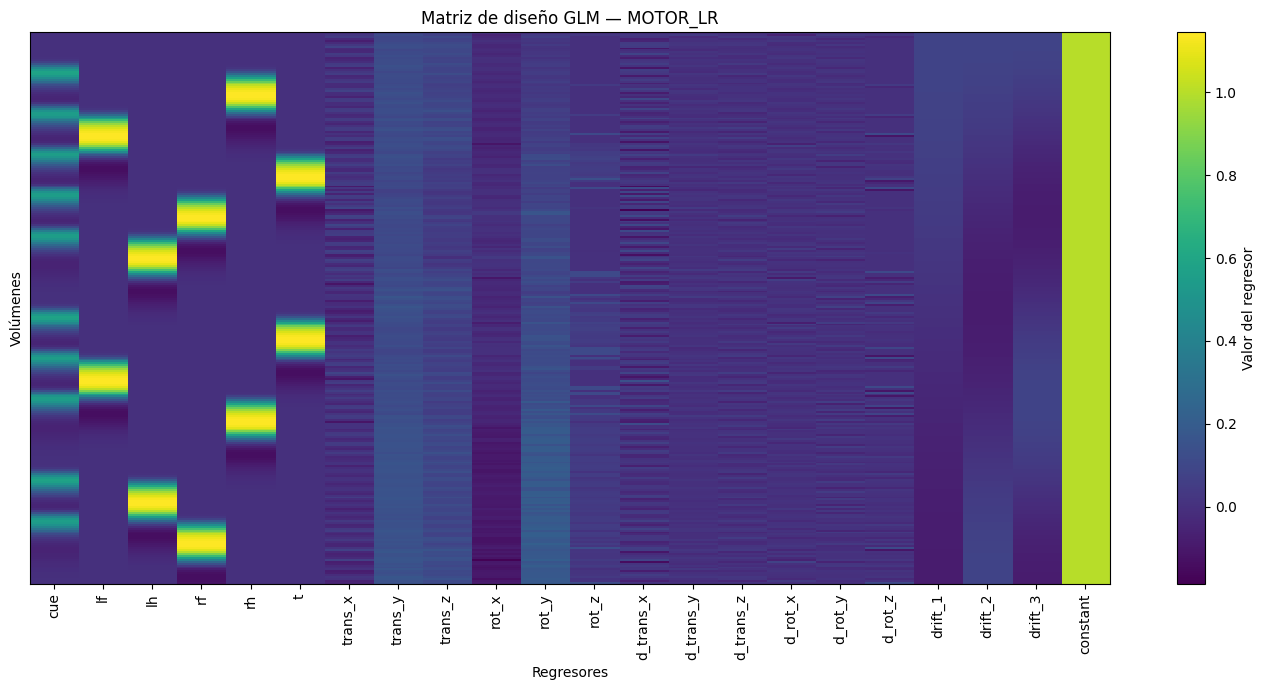

Figura guardada: /content/drive/MyDrive/Proyecto_PINN_HRF/results/figures/100206_motor_lr_design_matrix.png


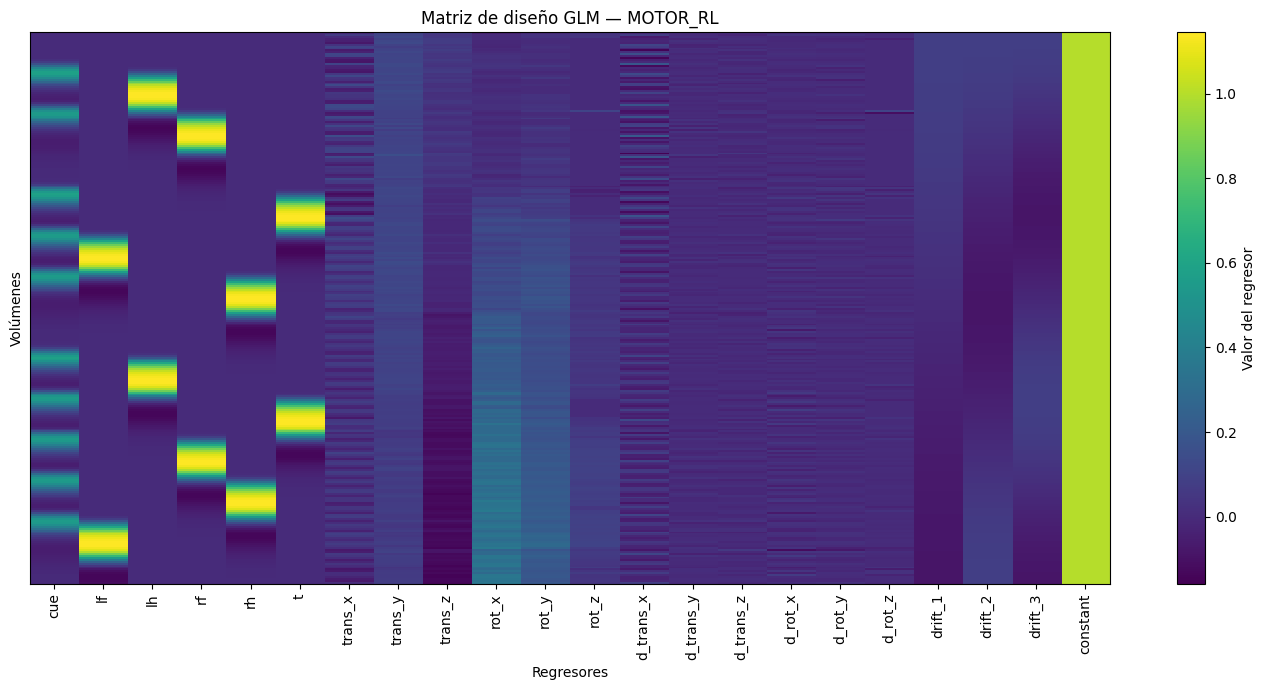

Figura guardada: /content/drive/MyDrive/Proyecto_PINN_HRF/results/figures/100206_motor_rl_design_matrix.png


In [10]:
def graficar_matriz_diseño(
    design_matrix: pd.DataFrame,
    run_name: str,
) -> None:
    plt.figure(figsize=(14, 7))

    plt.imshow(
        design_matrix.to_numpy(),
        aspect="auto",
        interpolation="nearest",
    )

    plt.xticks(
        np.arange(len(design_matrix.columns)),
        design_matrix.columns,
        rotation=90,
    )

    plt.yticks([])
    plt.xlabel("Regresores")
    plt.ylabel("Volúmenes")
    plt.title(f"Matriz de diseño GLM — {run_name}")
    plt.colorbar(label="Valor del regresor")
    plt.tight_layout()

    output_path = (
        FIGURES_DIR
        / f"{SUBJECT_ID}_{run_name.lower()}_design_matrix.png"
    )

    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Figura guardada:", output_path)


for run_name, data in data_by_run.items():
    graficar_matriz_diseño(
        data["design"],
        run_name,
    )

In [11]:
def ajustar_glm_roi(
    design_matrix: pd.DataFrame,
    bold_signal: np.ndarray,
) -> dict:
    """
    Ajusta un GLM mediante mínimos cuadrados ordinarios.
    """
    X = design_matrix.to_numpy(dtype=float)
    y = np.asarray(bold_signal, dtype=float).reshape(-1)

    beta, _, _, _ = np.linalg.lstsq(X, y, rcond=None)

    prediction = X @ beta
    residuals = y - prediction

    n_observations, n_parameters = X.shape
    degrees_of_freedom = n_observations - n_parameters

    residual_variance = (
        np.sum(residuals**2) / degrees_of_freedom
    )

    covariance_beta = (
        residual_variance * np.linalg.pinv(X.T @ X)
    )

    standard_error = np.sqrt(
        np.maximum(np.diag(covariance_beta), 0.0)
    )

    with np.errstate(divide="ignore", invalid="ignore"):
        t_values = np.divide(
            beta,
            standard_error,
            out=np.zeros_like(beta),
            where=standard_error > 0,
        )

    metrics = {
        "mse": mean_squared_error(y, prediction),
        "rmse": np.sqrt(mean_squared_error(y, prediction)),
        "mae": mean_absolute_error(y, prediction),
        "r2": r2_score(y, prediction),
    }

    coefficients = pd.DataFrame(
        {
            "regressor": design_matrix.columns,
            "beta_fraction": beta,
            "beta_percent": 100.0 * beta,
            "standard_error": standard_error,
            "t_value": t_values,
        }
    )

    return {
        "prediction": prediction,
        "residuals": residuals,
        "metrics": metrics,
        "coefficients": coefficients,
    }

In [12]:
roi_columns = {
    "M1_left": "bold_m1_left_fraction",
    "M1_right": "bold_m1_right_fraction",
}

glm_results = {}

for run_name, data in data_by_run.items():
    glm_results[run_name] = {}

    for roi_name, column_name in roi_columns.items():
        result = ajustar_glm_roi(
            data["design"],
            data["bold"][column_name].to_numpy(),
        )

        glm_results[run_name][roi_name] = result

        print(f"\n{run_name} — {roi_name}")
        print(result["metrics"])

        relevant = result["coefficients"].query(
            "regressor in ['rh', 'lh', 'rf', 'lf', 't', 'cue']"
        )

        display(relevant)


MOTOR_LR — M1_left
{'mse': 1.3409228031280624e-05, 'rmse': np.float64(0.0036618612796337087), 'mae': 0.002911976461071896, 'r2': 0.47206159446127716}


,regressor,beta_fraction,beta_percent,standard_error,t_value
0,cue,0.001138,0.113765,0.001185,0.960277
1,lf,-0.002390,-0.238963,0.000838,-2.851959
2,lh,-0.001569,-0.156918,0.001031,-1.521791
3,rf,-0.002824,-0.282400,0.001111,-2.542072
4,rh,0.008377,0.837687,0.000879,9.526183
5,t,-0.000172,-0.017181,0.001018,-0.168777



MOTOR_LR — M1_right
{'mse': 1.3275467399913008e-05, 'rmse': np.float64(0.003643551481715746), 'mae': 0.00297482836566708, 'r2': 0.5679843444828621}


,regressor,beta_fraction,beta_percent,standard_error,t_value
0,cue,-0.004879,-0.487943,0.001179,-4.139363
1,lf,-0.006134,-0.613366,0.000834,-7.357158
2,lh,0.003720,0.371997,0.001026,3.625756
3,rf,-0.008059,-0.805920,0.001105,-7.291084
4,rh,-0.005510,-0.551037,0.000875,-6.297886
5,t,-0.007383,-0.738297,0.001013,-7.289147



MOTOR_RL — M1_left
{'mse': 1.3962313040489056e-05, 'rmse': np.float64(0.0037366178611799544), 'mae': 0.003051747291811884, 'r2': 0.4329078003888406}


,regressor,beta_fraction,beta_percent,standard_error,t_value
0,cue,-0.001297,-0.129683,0.001180,-1.098827
1,lf,0.001420,0.142010,0.001230,1.154369
2,lh,-0.000451,-0.045120,0.000936,-0.482235
3,rf,-0.000110,-0.010985,0.000867,-0.126725
4,rh,0.010372,1.037240,0.001067,9.725102
5,t,0.002607,0.260714,0.000955,2.729202



MOTOR_RL — M1_right
{'mse': 1.5795204926418595e-05, 'rmse': np.float64(0.0039743181712614045), 'mae': 0.003109589964254463, 'r2': 0.5213512770104369}


,regressor,beta_fraction,beta_percent,standard_error,t_value
0,cue,-0.002085,-0.208513,0.001255,-1.661105
1,lf,-0.003053,-0.305266,0.001308,-2.333036
2,lh,0.009405,0.940480,0.000995,9.450598
3,rf,-0.003890,-0.389018,0.000922,-4.219214
4,rh,0.000646,0.064610,0.001134,0.569552
5,t,-0.002038,-0.203824,0.001016,-2.006054
